In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [3]:
drive.mount('/content/drive', force_remount=True)
path = "/content/drive/MyDrive/project_ml/Reviews.csv"
df = pd.read_csv(path)
df1 = df.copy()

Mounted at /content/drive


In [ ]:
df1.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [4]:
from sklearn.ensemble import RandomForestClassifier
# Préparation
df = df[['Text', 'Score']].dropna()
df['Sentiment'] = df['Score'].apply(lambda x: 0 if x <= 2 else (1 if x == 3 else 2))


dfs = []
for level in [0, 1, 2]:
    subset = df[df['Sentiment'] == level]
    dfs.append(subset.sample(min(len(subset), 40000), random_state=42))

df_balanced = pd.concat(dfs).sample(frac=1).reset_index(drop=True)

X = df_balanced['Text']
y = df_balanced['Sentiment']

print(f"Distribution vérifiée :\n{y.value_counts()}")

Distribution vérifiée :
Sentiment
0    40000
1    40000
2    40000
Name: count, dtype: int64


In [6]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Entraînement : {len(X_train)} | Test : {len(X_test)}")

Entraînement : 96000 | Test : 24000


In [7]:
from sklearn.ensemble import StackingClassifier, RandomForestClassifier
base_models = [
    ('nb', MultinomialNB(alpha=0.01)),
    ('svc', CalibratedClassifierCV(LinearSVC(dual="auto", C=1.0, random_state=42))),
    ('rf', RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42))
]


meta_learner = RandomForestClassifier(n_estimators=200, random_state=42)


model_stacking = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range=(1, 3),
        max_features=40000,
        stop_words='english',
        sublinear_tf=True
    )),
    ('stacking', StackingClassifier(
        estimators=base_models,
        final_estimator=meta_learner,
        cv=5,
        stack_method='predict_proba'
    ))
])

print("Entraînement du modèle...")
model_stacking.fit(X_train, y_train)

Entraînement du modèle...


Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=40000, ngram_range=(1, 3),
                                 stop_words='english', sublinear_tf=True)),
                ('stacking',
                 StackingClassifier(cv=5,
                                    estimators=[('nb',
                                                 MultinomialNB(alpha=0.01)),
                                                ('svc',
                                                 CalibratedClassifierCV(estimator=LinearSVC(random_state=42))),
                                                ('rf',
                                                 RandomForestClassifier(max_depth=10,
                                                                        random_state=42))],
                                    final_estimator=RandomForestClassifier(n_estimators=200,
                                                                           random_state=42),
                                    stack_method='predict_proba'))])


 Rapport de Performance Final :
              precision    recall  f1-score   support

     Négatif       0.77      0.79      0.78      8000
      Neutre       0.71      0.67      0.69      8000
     Positif       0.81      0.84      0.82      8000

    accuracy                           0.77     24000
   macro avg       0.76      0.77      0.77     24000
weighted avg       0.76      0.77      0.77     24000



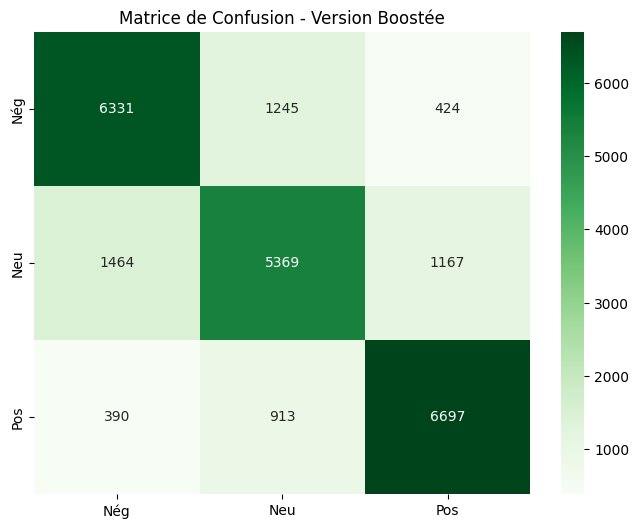

✅ Modèle exporté !


In [8]:
from sklearn.metrics import classification_report, confusion_matrix

# Prédictions
y_pred = model_stacking.predict(X_test)

# Rapport détaillé
print("\n Rapport de Performance Final :")
print(classification_report(y_test, y_pred, target_names=['Négatif', 'Neutre', 'Positif']))
# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', # Couleur changée pour différencier la version
            xticklabels=['Nég', 'Neu', 'Pos'], yticklabels=['Nég', 'Neu', 'Pos'])
plt.title('Matrice de Confusion - Version Boostée')
plt.show()

# Exportation
import joblib
joblib.dump(model_stacking, '/content/drive/MyDrive/project_ml/sentiment_stacking_pro_v2.joblib')
print("✅ Modèle exporté !")

In [9]:
# Échantillon de test "Pro & Mixte"
pro_samples = [
    # --- AMBIGUÏTÉ ET NUANCE (Cible : Neutre) ---
    "The interface is intuitive but the constant updates are quite annoying.",
    "It's not a revolution, but it gets the job done for the price.",
    "While the battery life is great, the screen resolution is underwhelming.",

    # --- SARCASME ET IRONIE (Cible : Négatif) ---
    "Oh great, another 'high-quality' product that breaks after two days. Fantastic.",
    "Thanks for the empty box, really appreciate your professionalism.",
    "If you love waiting three weeks for a broken item, this is for you!",

    # --- NÉGATION INVERSÉE (Cible : Positif) ---
    "I was told it wouldn't be worth it, but I couldn't be happier with my purchase.",
    "Not the cheapest, but definitely the most reliable tool in my kit.",
    "I can't say anything bad about this experience, honestly.",

    # --- COMPARAISON TECHNIQUE (Cible : Neutre ou Positif) ---
    "Better than the previous version, though still lacks some pro features.",
    "Compared to the competition, it's a solid 3-star performer.",

    # --- SENTIMENT EXTRÊME (Cible : Négatif) ---
    "A total disaster from start to finish. Avoid like the plague."
]

# Inférence
labels = {0: "Négatif", 1: "Neutre", 2: "Positif"}
probs = model_stacking.predict_proba(pro_samples)
preds = model_stacking.predict(pro_samples)

print(f"{'Texte du Test':<65} | {'Prédiction':<10} | {'Confiance'}")
print("-" * 90)

for i, text in enumerate(pro_samples):
    conf = np.max(probs[i]) * 100
    print(f"{text[:63]:<65} | {labels[preds[i]]:<10} | {conf:>6.1f}%")

Texte du Test                                                     | Prédiction | Confiance
------------------------------------------------------------------------------------------
The interface is intuitive but the constant updates are quite a   | Neutre     |   77.0%
It's not a revolution, but it gets the job done for the price.    | Neutre     |   52.0%
While the battery life is great, the screen resolution is under   | Neutre     |   54.5%
Oh great, another 'high-quality' product that breaks after two    | Positif    |   93.5%
Thanks for the empty box, really appreciate your professionalis   | Positif    |   70.0%
If you love waiting three weeks for a broken item, this is for    | Négatif    |   59.5%
I was told it wouldn't be worth it, but I couldn't be happier w   | Positif    |   67.0%
Not the cheapest, but definitely the most reliable tool in my k   | Positif    |   80.5%
I can't say anything bad about this experience, honestly.         | Positif    |   44.5%
Better than the p